## 4. Modelling: TF-IDF + ML Classifiers, and VADER Lexicon Baseline
Trains Logistic Regression, Multinomial Naive Bayes and Linear SVM on TF-IDF features; compares against an unsupervised VADER lexicon baseline; visualises confusion matrix and top predictive words.

In [2]:
!pip install vaderSentiment


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Rows used for modelling: 22168


'\n=== Logistic Regression ==='

              precision    recall  f1-score   support

    Negative       0.83      0.78      0.81      1877
     Neutral       0.31      0.43      0.36       622
    Positive       0.82      0.75      0.78      1935

    accuracy                           0.72      4434
   macro avg       0.65      0.66      0.65      4434
weighted avg       0.75      0.72      0.73      4434



'\n=== Multinomial Naive Bayes ==='

              precision    recall  f1-score   support

    Negative       0.76      0.89      0.82      1877
     Neutral       0.67      0.02      0.03       622
    Positive       0.76      0.87      0.81      1935

    accuracy                           0.76      4434
   macro avg       0.73      0.59      0.55      4434
weighted avg       0.75      0.76      0.71      4434



...

              precision    recall  f1-score   support

    Negative       0.81      0.81      0.81      1877
     Neutral       0.33      0.30      0.31       622
    Positive       0.78      0.81      0.80      1935

    accuracy                           0.74      4434
   macro avg       0.64      0.64      0.64      4434
weighted avg       0.73      0.74      0.73      4434



'\nModel comparison:\n'

,accuracy,macro_precision,macro_recall,macro_f1
Logistic Regression,0.720117,0.650648,0.656062,0.648979
Multinomial Naive Bayes,0.759811,0.728973,0.592920,0.554614
Linear SVM,0.735002,0.638549,0.636387,0.637190


Best model by macro-F1: {best_name}

VADER lexicon-baseline accuracy vs rating-derived label: 0.647


C:\Users\EL GHANDOUR\AppData\Local\Temp\ipykernel_14504\4209488110.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x="rating_num", y="vader_compound", palette="coolwarm", ax=ax)


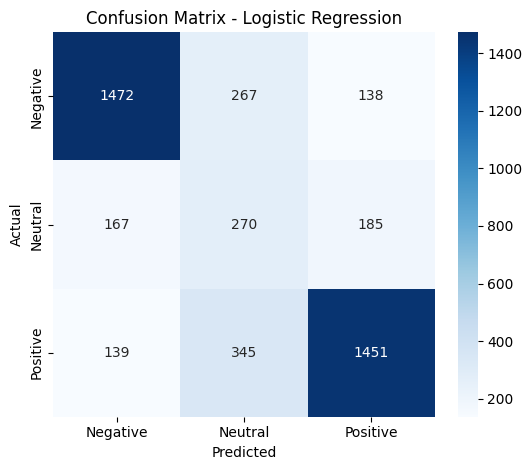

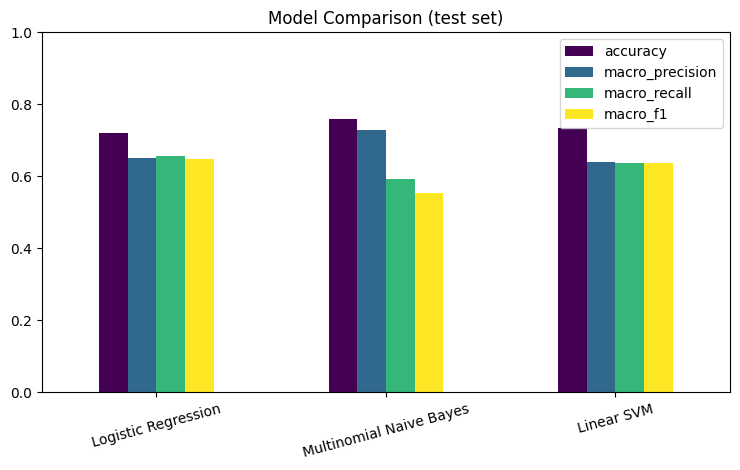

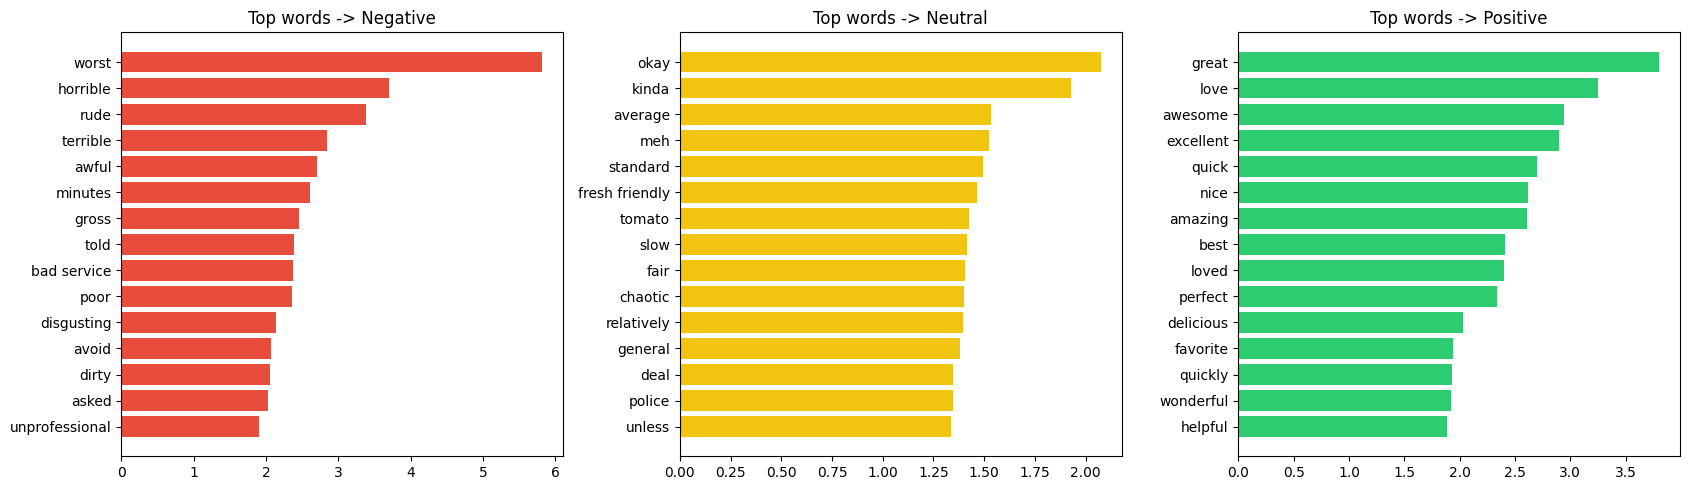

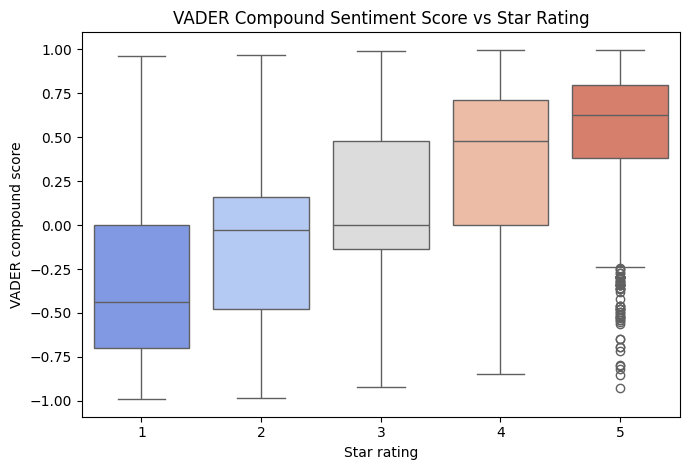


Saved model outputs & figures.


['tfidf_vectorizer.pkl']

In [1]:
%matplotlib inline
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

FIG = "Figures"
df = pd.read_csv("text_reviews_processed.csv")
df = df.dropna(subset=["review_processed"])
print("Rows used for modelling:", len(df))

X_text = df["review_processed"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(class_weight="balanced"),
}

results = {}
preds_store = {}
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    preds_store[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    results[name] = {"accuracy": acc, "macro_precision": prec, "macro_recall": rec, "macro_f1": f1}
    display(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame(results).T
results_df.to_csv("model_results.csv")
display("\nModel comparison:\n", results_df)

# ---- Best model selection ----------------------------------------------
best_name = results_df["macro_f1"].idxmax()
print("Best model by macro-F1: {best_name}")

# ---- Confusion matrix for best model ------------------------------------
order = ["Negative", "Neutral", "Positive"]
cm = confusion_matrix(y_test, preds_store[best_name], labels=order)
fig, ax = plt.subplots(figsize=(5.5, 4.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=order, yticklabels=order, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.savefig(f"{FIG}/07_confusion_matrix.png")
# plt.close()

# ---- Model comparison bar chart -----------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.8))
results_df[["accuracy", "macro_precision", "macro_recall", "macro_f1"]].plot(
    kind="bar", ax=ax, colormap="viridis")
ax.set_title("Model Comparison (test set)")
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f"{FIG}/08_model_comparison.png")
# plt.close()

# ---- Most influential words (Logistic Regression coefficients) ---------
logreg = models["Logistic Regression"]
feat_names = np.array(tfidf.get_feature_names_out())
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, cls, color in zip(axes, order, ["#e74c3c", "#f1c40f", "#2ecc71"]):
    idx = list(logreg.classes_).index(cls)
    coefs = logreg.coef_[idx]
    top_idx = np.argsort(coefs)[-15:]
    ax.barh(feat_names[top_idx], coefs[top_idx], color=color)
    ax.set_title(f"Top words -> {cls}")
plt.tight_layout()
plt.savefig(f"{FIG}/09_top_predictive_words.png")
# plt.close()

# =========================================================================
# Unsupervised lexicon-based baseline: VADER sentiment score vs star rating
# =========================================================================
analyzer = SentimentIntensityAnalyzer()
sample = df.sample(n=min(8000, len(df)), random_state=42).copy()
sample["vader_compound"] = sample["review_clean"].astype(str).apply(
    lambda t: analyzer.polarity_scores(t)["compound"])

def vader_label(c):
    if c <= -0.05:
        return "Negative"
    elif c >= 0.05:
        return "Positive"
    return "Neutral"

sample["vader_sentiment"] = sample["vader_compound"].apply(vader_label)
vader_acc = accuracy_score(sample["sentiment"], sample["vader_sentiment"])
print(f"\nVADER lexicon-baseline accuracy vs rating-derived label: {vader_acc:.3f}")

fig, ax = plt.subplots(figsize=(7, 4.8))
sns.boxplot(data=sample, x="rating_num", y="vader_compound", palette="coolwarm", ax=ax)
ax.set_title("VADER Compound Sentiment Score vs Star Rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("VADER compound score")
plt.tight_layout()
plt.savefig(f"{FIG}/10_vader_vs_rating.png")
# plt.close()

plt.show()

summary = {
    "best_supervised_model": best_name,
    "best_supervised_macro_f1": float(results_df.loc[best_name, "macro_f1"]),
    "best_supervised_accuracy": float(results_df.loc[best_name, "accuracy"]),
    "vader_baseline_accuracy": float(vader_acc),
    "n_train": len(X_train), "n_test": len(X_test),
}
with open("summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved model outputs & figures.")


joblib.dump(logreg, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
